In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, MaxAbsScaler, QuantileTransformer, PolynomialFeatures
from sklearn.feature_selection import SelectKBest, chi2, RFE, mutual_info_classif
from sklearn.linear_model import LassoCV, RidgeCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer

In [2]:
# Load dataset
df = pd.read_csv("cleaned_startup_data.csv")
df.head()

,Unnamed: 0.1,category_code,status,founded_at,country_code,first_funding_at,last_funding_at,funding_rounds,funding_total_usd,first_milestone_at,...,lng,founded_at_year,first_funding_at_year,last_funding_at_year,first_milestone_at_year,last_milestone_at_year,active_status,isClosed,founded_year,company_age
0,13,41,acquired,2007-10-01,103,2008-02-26,2008-02-26,1.0,5000000.0,2008-05-01,...,-122.083851,2007,2008.0,2008.0,2008.000000,2012.000000,0,1,2007,18
1,20,4,operating,2003-01-01,103,2011-03-08,2012-01-26,3.0,10125293.0,2010-01-01,...,-97.743061,2003,2011.0,2012.0,2010.000000,2010.000000,1,0,2003,22
2,26,22,operating,2003-11-01,4,2003-11-01,2003-11-01,1.0,250000.0,2007-11-01,...,153.025124,2003,2003.0,2003.0,2007.000000,2007.000000,1,0,2003,22
3,32,8,operating,2010-10-01,103,2011-04-16,2011-04-16,1.0,100000.0,2010-10-01,...,-64.519016,2010,2011.0,2011.0,2010.000000,2010.000000,1,0,2010,15
4,36,20,operating,2006-01-01,103,2011-09-06,2012-07-10,2.0,11300000.0,NaN,...,-71.007822,2006,2011.0,2012.0,2010.244157,2010.985878,1,0,2006,19


In [3]:
# Check data types and missing values
df.info()

# Summary statistics
df.describe()

# Check target variable (assuming 'status' or similar exists)
df['status'].value_counts()

# Separate numeric and categorical columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print("Numeric Columns:", numeric_cols)
print("Categorical Columns:", categorical_cols)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16882 entries, 0 to 16881
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unnamed: 0.1             16882 non-null  int64  
 1   category_code            16882 non-null  int64  
 2   status                   16882 non-null  object 
 3   founded_at               16882 non-null  object 
 4   country_code             16882 non-null  int64  
 5   first_funding_at         16831 non-null  object 
 6   last_funding_at          16831 non-null  object 
 7   funding_rounds           16882 non-null  float64
 8   funding_total_usd        16882 non-null  float64
 9   first_milestone_at       10055 non-null  object 
 10  last_milestone_at        10055 non-null  object 
 11  milestones               16882 non-null  float64
 12  relationships            16882 non-null  float64
 13  lat                      16882 non-null  float64
 14  lng                   

C:\Users\anike\AppData\Local\Temp\ipykernel_19228\2475052535.py:3: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(df.corr(), annot=False, cmap="coolwarm")


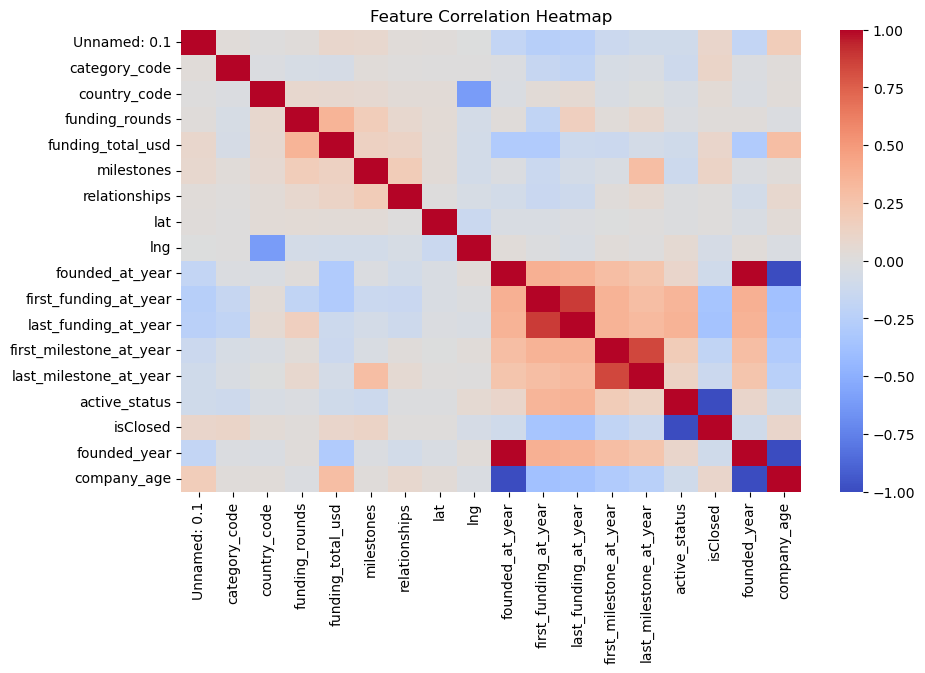

In [4]:
# Correlation heatmap for multicollinearity
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=False, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

# 2. Feature Selection

In [5]:
# Select only numeric features
X = df.select_dtypes(include=['float64','int64']).copy()

# Drop columns with constant values (since VIF can't be computed)
X = X.loc[:, X.apply(pd.Series.nunique) > 1]

# Fill missing values (if any) with median
X = X.fillna(X.median())

# Reset index to avoid alignment issues
X = X.reset_index(drop=True)

# Calculate VIF
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_data)

C:\Users\anike\anaconda3\Lib\site-packages\statsmodels\stats\outliers_influence.py:195: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


                    Feature       VIF
0              Unnamed: 0.1  1.084285
1             category_code  1.051033
2              country_code  1.634959
3            funding_rounds  2.150154
4         funding_total_usd  1.339701
5                milestones  1.678624
6             relationships  1.075327
7                       lat  1.027229
8                       lng  1.661047
9           founded_at_year       inf
10    first_funding_at_year  9.116154
11     last_funding_at_year  8.778601
12  first_milestone_at_year  4.936664
13   last_milestone_at_year  5.257726
14            active_status       inf
15                 isClosed       inf
16             founded_year       inf
17              company_age       inf


In [6]:
# Use active_status as target
X = df.drop(columns=["active_status"])
y = df["active_status"]

# Encode categorical features
for col in X.select_dtypes(include=["object"]).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

# 🔧 Fix: handle missing values
X = X.fillna(0)   # you can also try median/mode imputation if better

# Scale for Lasso
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- Mutual Information ---
mi_scores = mutual_info_classif(X, y, discrete_features="auto")
mi_scores = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)
print("\n🔹 Mutual Information Scores:\n", mi_scores)

# --- Random Forest ---
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)
rf_importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\n🔹 Random Forest Feature Importances:\n", rf_importances)

# --- Lasso ---
lasso = LassoCV(cv=5, random_state=42)
lasso.fit(X_scaled, y)
lasso_importances = pd.Series(lasso.coef_, index=X.columns).sort_values(key=abs, ascending=False)
print("\n🔹 Lasso Feature Coefficients:\n", lasso_importances)

# --- Domain Expert Input ---
domain_expert_features = ["funding_total_usd", "country_code", "milestones"]
print("\n🔹 Domain Expert Selected Features:", domain_expert_features)

# --- Final Features ---
final_features = set(mi_scores.head(10).index) | set(rf_importances.head(10).index) | set(domain_expert_features)
print("\n✅ Final Selected Features:\n", final_features)



🔹 Mutual Information Scores:
 status                     0.411395
isClosed                   0.408581
last_funding_at            0.081935
last_funding_at_year       0.081641
first_funding_at           0.078602
first_funding_at_year      0.070668
first_milestone_at         0.037851
Unnamed: 0.1               0.034345
first_milestone_at_year    0.034266
founded_at                 0.033566
company_age                0.028905
founded_year               0.028190
founded_at_year            0.027761
last_milestone_at          0.025125
category_code              0.020117
last_milestone_at_year     0.017359
milestones                 0.012144
funding_total_usd          0.010557
lat                        0.009466
lng                        0.009192
country_code               0.006569
relationships              0.001708
funding_rounds             0.001545
dtype: float64

🔹 Random Forest Feature Importances:
 status                     0.467442
isClosed                   0.430886
last_funding_at

# 3. Create New Features

In [7]:
# Example: Mathematical transformations
if 'funding_total_usd' in df.columns and 'funding_rounds' in df.columns:
    df['funding_per_round'] = df['funding_total_usd'] / (df['funding_rounds'] + 1)

# Aggregations: Example grouping if 'year' exists
if 'first_funding_at_year' in df.columns:
    df['mean_funding_by_year'] = df.groupby('first_funding_at_year')['funding_total_usd'].transform('mean')

# Date and time feature extraction
if 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'])
    df['year'] = df['date'].dt.year
    df['month'] = df['date'].dt.month
    df['day_of_week'] = df['date'].dt.dayofweek

# 4. Feature Transformation

In [8]:
# Normalization (MinMax)
scaler_minmax = MinMaxScaler()
df[numeric_cols] = scaler_minmax.fit_transform(df[numeric_cols])

# Standardization
scaler_std = StandardScaler()
df[numeric_cols] = scaler_std.fit_transform(df[numeric_cols])

# Log Transformation (for skewed columns)
for col in numeric_cols:
    if (df[col] > 0).all():  # log only positive values
        df[col+'_log'] = np.log1p(df[col])

# Polynomial Features (example with top 2 features)
poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_poly = poly.fit_transform(df[numeric_cols[:2]])
poly_features = poly.get_feature_names_out(numeric_cols[:2])
df_poly = pd.DataFrame(X_poly, columns=poly_features)
df = pd.concat([df, df_poly], axis=1)


# 5. Feature Scaling

In [15]:
# ✅ Step 1: Recalculate numeric columns AFTER feature engineering
numeric_data = df.select_dtypes(include=['int64', 'float64'])

# ✅ Step 2: Use numeric_data.columns for column names
cols = numeric_data.columns.tolist()
print(f"Number of numeric columns: {len(cols)}")  # Debug check

# ✅ Step 3: Apply different scaling methods and store in separate DataFrames

# 1. Min-Max Scaling
scaler_minmax = MinMaxScaler()
df_minmax = pd.DataFrame(scaler_minmax.fit_transform(numeric_data), columns=cols)

# 2. Standard Scaling (Z-score)
scaler_std = StandardScaler()
df_std = pd.DataFrame(scaler_std.fit_transform(numeric_data), columns=cols)

# 3. Robust Scaling (less sensitive to outliers)
scaler_robust = RobustScaler()
df_robust = pd.DataFrame(scaler_robust.fit_transform(numeric_data), columns=cols)

# 4. Max-Abs Scaling
scaler_maxabs = MaxAbsScaler()
df_maxabs = pd.DataFrame(scaler_maxabs.fit_transform(numeric_data), columns=cols)

# 5. Quantile Transformation (normal distribution)
qt = QuantileTransformer(output_distribution='normal', random_state=42)
df_quantile = pd.DataFrame(qt.fit_transform(numeric_data), columns=cols)

print("✅ Scaling completed successfully!")
print("Scaled data shapes:", df_minmax.shape, df_std.shape, df_robust.shape)

Number of numeric columns: 23
✅ Scaling completed successfully!
Scaled data shapes: (16882, 23) (16882, 23) (16882, 23)


# 6. Feature Reduction

In [ ]:
# Define target column (change if your target is named differently)
target_col = "status"

# Encode target if categorical
if df[target_col].dtype == "object":
    le = LabelEncoder()
    df[target_col] = le.fit_transform(df[target_col])

X = df.drop(columns=[target_col])
y = df[target_col]

# Encode categorical features
X = pd.get_dummies(X, drop_first=True)

# --------------------------
# Handle missing values
# --------------------------
# Drop columns that are completely NaN
X = X.dropna(axis=1, how="all")

# Now impute remaining missing values
imputer = SimpleImputer(strategy="median")
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

# Fit and transform
X_imputed_array = imputer.fit_transform(X)

# Use the *retained feature names* from imputer
X_imputed = pd.DataFrame(X_imputed_array, columns=X.columns[imputer.statistics_ != np.nan])


# --------------------------
# Scale features
# --------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# --------------------------
# 1. Principal Component Analysis (PCA)
# --------------------------
pca = PCA(n_components=5)  # keep 5 components
X_pca = pca.fit_transform(X_scaled)
print("Explained Variance Ratio (PCA):", pca.explained_variance_ratio_)

# --------------------------
# 2. Statistical Tests (Chi2, ANOVA)
# --------------------------
# Chi2 requires non-negative values -> use MinMaxScaler
chi2_selector = SelectKBest(score_func=chi2, k=5)
X_chi2 = chi2_selector.fit_transform(MinMaxScaler().fit_transform(X_imputed), y)
selected_chi2_features = X.columns[chi2_selector.get_support()]
print("Chi-Square Selected Features:", selected_chi2_features.tolist())

# ANOVA (for classification tasks)
from sklearn.feature_selection import SelectKBest, f_classif

f_selector = SelectKBest(score_func=f_classif, k=10)
f_selector.fit(X_imputed, y)

f_scores = pd.DataFrame({
    "Feature": X.columns,
    "F Score": f_selector.scores_
}).sort_values(by="F Score", ascending=False)

print("\nTop 10 Features by ANOVA F-test:\n", f_scores.head(10))


# --------------------------
# 3. Embedded Methods (Lasso, Ridge)
# --------------------------
lasso = LassoCV(cv=5, random_state=42)
lasso.fit(X_scaled, y)
lasso_importances = pd.Series(lasso.coef_, index=X.columns).sort_values(key=abs, ascending=False)
print("\nTop 10 Features by LASSO:\n", lasso_importances.head(10))
# --------------------------
# 4. Recursive Feature Elimination (RFE)
# --------------------------
model = LogisticRegression(max_iter=500, solver="liblinear")
rfe = RFE(model, n_features_to_select=5)
X_rfe = rfe.fit_transform(X_scaled, y)
selected_rfe_features = X.columns[rfe.support_]
print("RFE Selected Features:", selected_rfe_features.tolist())

Explained Variance Ratio (PCA): [0.00079251 0.00046136 0.00045902 0.00045487 0.00044658]
Chi-Square Selected Features: ['funding_total_usd', 'active_status', 'isClosed', 'founded_at_1999-10-01', 'first_milestone_at_2010-08-27']

Top 10 Features by ANOVA F-test:
                     Feature     F Score
11     last_funding_at_year  893.415671
19     mean_funding_by_year  846.361554
10    first_funding_at_year  838.867576
6             relationships  326.959587
16             founded_year  290.463106
9           founded_at_year  290.463106
17              company_age  290.463106
12  first_milestone_at_year  242.596619
4         funding_total_usd  231.572679
18        funding_per_round  228.534381


In [ ]:
df